# Loading Supermarket & Shopping list

In [1]:
from supermarket import Grid
from shopping_list import ShoppingList
import distance

grid = Grid("grid_eng.txt")
shopping_list = ShoppingList.load_from_file("Long_shopping_list.txt")
J_product_category, P_product_category, product_type_indizes = distance.compute_optimal_trajectories(grid, (5,4), (5,0))
J_product, P_product = distance.create_product_cost_path_matrix(shopping_list, J_product_category, P_product_category, product_type_indizes)


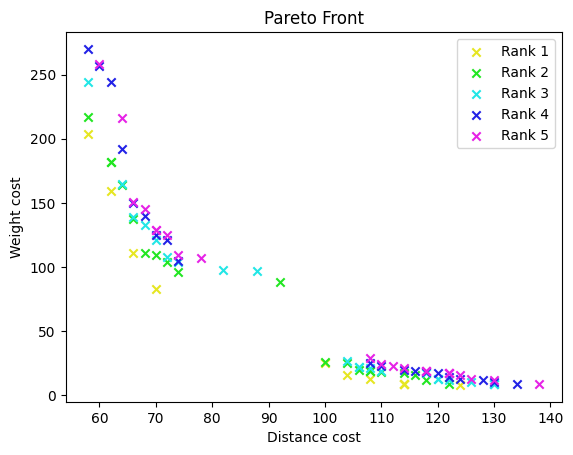

In [2]:
from shopping_list import ShoppingList
import order_functions

def compute_weight_cost(order, shopping_list: ShoppingList):
    """
    Crushing penalty:
    If a heavier product is packed later (thus lies on top)
    of a lighter product, a penalty proportional to the
    weight difference is added.
    
    Cost = 0  -> perfectly sorted heavy -> light
    """
    assert len(order) == len(shopping_list)

    total_cost = 0
    weights_list = []

    for i in range(len(order)):
        product_idx_bottom = order[i]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
        weight_bottom = shopping_list.products[product_idx_bottom].weight
        weights_list.append(weight_bottom)
        for j in range(i + 1, len(order)):
            product_idx_top = order[j]-1 # -1 because order goes from 1 to n but in products we use the index, which starts with 0
            weight_top = shopping_list.products[product_idx_top].weight

            # crushing condition: heavier on top of lighter
            if weight_top > weight_bottom:
                total_cost += (weight_top - weight_bottom)
    #print(f"Weights: {weights_list}")
    return total_cost
import random
def generate_weightgreedy_random_order(shopping_list: ShoppingList, alpha=0.5):
    products = shopping_list.products
    n = len(products)

    order = []
    remaining_product_indices = list(range(0, n))  # Produkt-Indizes

    for _ in range(n):
        # Gewichte der noch nicht gewählten Produkte
        weights = [products[i].weight for i in remaining_product_indices]

        max_weight = max(weights)
        min_weight = min(weights)

        # Für heavy-first: obere Grenze definieren
        cutoff_value = max_weight - alpha * (max_weight - min_weight)

        # RCL: alle Produkte mit Gewicht >= cutoff
        rcl = [i for i in remaining_product_indices 
               if products[i].weight >= cutoff_value]

        winner = random.choice(rcl)

        order.append(winner+1) # order number is index + 1 (because 0 == start)
        remaining_product_indices.remove(winner)
    return order

import numpy as np

def pareto_rank_2_with_crowding(cost1, cost2):
    """
    Computes Pareto ranks for two objectives (minimization) and sorts
    solutions within each front by crowding distance (descending).

    Returns:
        - final_ranking: list of indices sorted by Pareto rank and crowding distance
        - ranks: list of Pareto ranks for each solution (rank 0 = best front)
    """
    n = len(cost1)
    assert n == len(cost2)
    
    ranks = [-1] * n
    remaining = set(range(n))
    current_rank = 1
    fronts = []

    # Step 1: Identify Pareto fronts
    while remaining:
        current_front = []
        for i in remaining:
            dominated = False
            for j in remaining:
                if j == i:
                    continue
                if (cost1[j] <= cost1[i] and cost2[j] <= cost2[i]) and \
                   (cost1[j] < cost1[i] or cost2[j] < cost2[i]):
                    dominated = True
                    break
            if not dominated:
                current_front.append(i)

        for i in current_front:
            ranks[i] = current_rank
            remaining.remove(i)

        fronts.append(current_front)
        current_rank += 1

    # Step 2: Compute crowding distance for each front
    crowding_distances = np.zeros(n)
    for front in fronts:
        if len(front) == 1:
            crowding_distances[front[0]] = float('inf')
            continue

        front_cost1 = np.array([cost1[i] for i in front])
        front_cost2 = np.array([cost2[i] for i in front])
        
        # Sort by each objective
        sorted1 = np.argsort(front_cost1)
        sorted2 = np.argsort(front_cost2)
        
        # Boundaries get infinite distance
        crowding_distances[front[sorted1[0]]] = float('inf')
        crowding_distances[front[sorted1[-1]]] = float('inf')
        crowding_distances[front[sorted2[0]]] = float('inf')
        crowding_distances[front[sorted2[-1]]] = float('inf')
        
        # Normalize ranges
        norm1 = front_cost1.max() - front_cost1.min() or 1.0
        norm2 = front_cost2.max() - front_cost2.min() or 1.0

        # Interior points
        for k in range(1, len(front)-1):
            crowding_distances[front[sorted1[k]]] += (front_cost1[sorted1[k+1]] - front_cost1[sorted1[k-1]]) / norm1
            crowding_distances[front[sorted2[k]]] += (front_cost2[sorted2[k+1]] - front_cost2[sorted2[k-1]]) / norm2

    # Step 3: Produce final ranking (rank ascending, crowding distance descending)
    all_indices = list(range(n))
    final_ranking = sorted(all_indices, key=lambda i: (ranks[i], -crowding_distances[i]))

    return final_ranking, ranks, crowding_distances
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors

def plot_pareto_2(ranks, costx, costy, xlabel = "Cost x", ylabel = "Cost y", max_legend_ranks=5, plot_high_ranks = True):
    """
    Uses pareto_rank_2 and plots Pareto fronts.
    
    - First max_legend_ranks fronts get distinct colors + legend entry
    - Remaining fronts are plotted in black with a single legend entry "Rank > max_legend_ranks-1"
    """
    max_rank = max(ranks)
    num_fronts = max_rank

    # Farben nur für die ersten expliziten Fronten erzeugen
    colors = [
        mcolors.hsv_to_rgb((i / max_legend_ranks, 0.85, 0.9))
        for i in range(max_legend_ranks)
    ]

    plt.figure()
    black_plotted = False  # Flag, damit schwarzes Label nur einmal in der Legende erscheint
    for r in range(1,num_fronts+1):
        indices = [i for i in range(len(ranks)) if ranks[i] == r]
        x_vals = [costx[i] for i in indices]
        y_vals = [costy[i] for i in indices]

        if r < max_legend_ranks:
            plt.scatter(
                x_vals,
                y_vals,
                color=colors[r],
                label=f"Rank {r}",
                marker="x"
            )
        elif plot_high_ranks:
            label = f"Rank ≥ {max_legend_ranks}" if not black_plotted else None
            plt.scatter(
                x_vals,
                y_vals,
                color="black",
                marker="x",
                label=label
            )
            black_plotted = True

    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.title("Pareto Front")
    plt.legend()
    plt.show()


import distance
#order = order_functions.generate_random_order(len(shopping_list))
m = 1000
weight_costs, distance_costs = [], []
for i in range(m):
    if i < m/2:
        order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
    else:
        order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
    weight_cost = compute_weight_cost(order, shopping_list)
    weight_costs.append(weight_cost)
    distance_cost = distance.compute_timecost_from_middle_indices_order(order, J_product)
    distance_costs.append(distance_cost)
import matplotlib.pyplot as plt
final_ranking, ranks, crowding_distances = pareto_rank_2_with_crowding(distance_costs, weight_costs)
plot_pareto_2(ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=False)


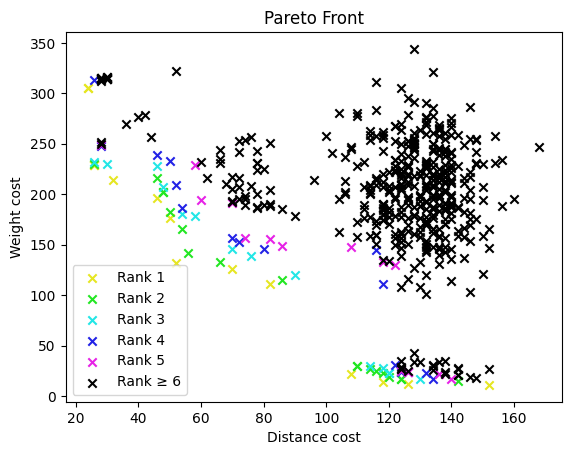

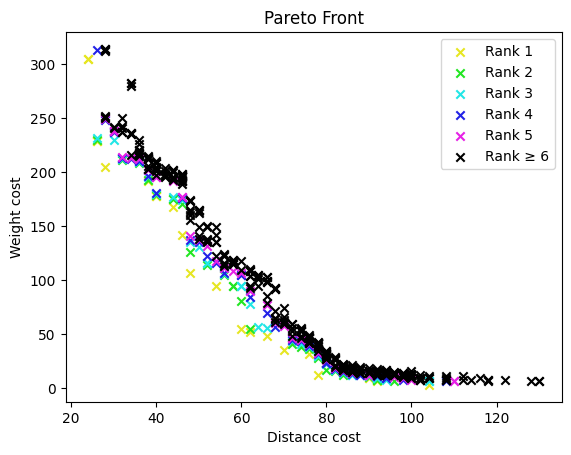

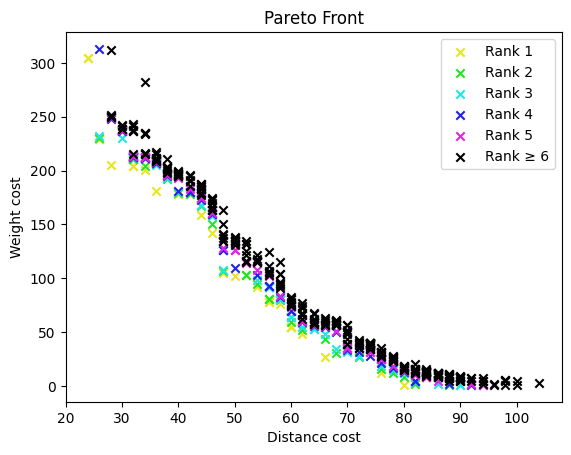

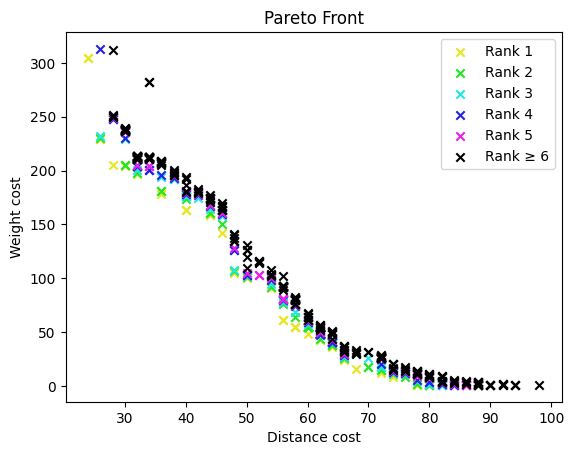

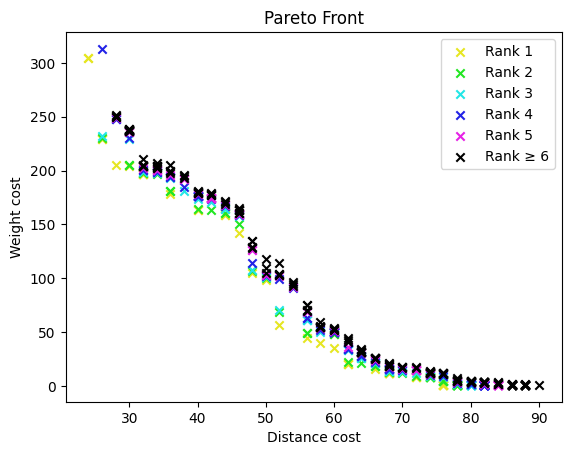

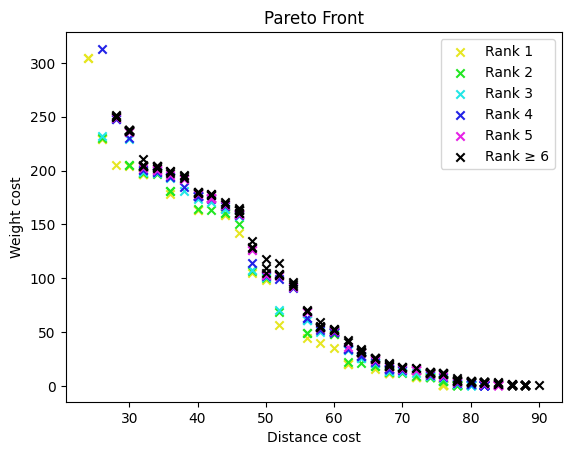

In [16]:
def simple_selection(ranking, population, generation_size):
    ranking = ranking[:generation_size*2]
    parents = [population[rank] for rank in ranking]
    return parents

def evaluate_population(population, shopping_list, J_product):
    # Compute Costs and ranking for population
    weight_costs = [compute_weight_cost(order, shopping_list) for order in population]
    distance_costs = [distance.compute_timecost_from_middle_indices_order(order, J_product) for order in population]
    ranking, pareto_ranks, crowding_distances = pareto_rank_2_with_crowding(distance_costs, weight_costs)
    pareto_front_indices = [i for i, r in enumerate(pareto_ranks) if r == min(pareto_ranks)]
    pareto_front = [population[i] for i in pareto_front_indices]
    return ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs

def crossover_reproduction(selected_population:list):
    # s = len(selected population) = g/2
    # O(g * n)
    number_of_products = len(selected_population[0])
    crossover_line = int(number_of_products/2)
    children = []
    for i in range(0,len(selected_population),2):
        male, female = selected_population[i], selected_population[i+1]
        child = male[:crossover_line]
        while len(child) < len(male):
            child.append(next(product for product in female if (product not in child)))
        children.append(child)
    return children

def replacement(population_size, ranking, population, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs):
    # Reihenfolge nach Ranking
    sorted_indices = ranking[:population_size]  # top N indices
    
    # Population kürzen
    population = [population[i] for i in sorted_indices]
    pareto_ranks = [pareto_ranks[i] for i in sorted_indices]
    weight_costs = [weight_costs[i] for i in sorted_indices]
    distance_costs = [distance_costs[i] for i in sorted_indices]
    crowding_distances = [crowding_distances[i] for i in sorted_indices]

    # Erste Pareto-Front aktualisieren
    min_rank = min(pareto_ranks)
    pareto_front = [population[i] for i, r in enumerate(pareto_ranks) if r == min_rank]

    # Ranking neu setzen (0..population_size-1)
    ranking = list(range(len(population)))

    return population, pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, distance_costs

def remove_duplicates(population):
    seen = set()
    new_pop = []
    for ind in population:
        key = tuple(ind)
        if key not in seen:
            seen.add(key)
            new_pop.append(ind)
    return new_pop
import time
def evolution_2(shopping_list:ShoppingList, J_product, population_size = 100, generation_size = 10, patience = 10, mutation_probability = 0.5, max_generations = 200):
    # Generate initial population
    # strategic Multi-Start-Heuristic
    population = []
    for i in range(population_size):
        if i < 0.7*population_size:
            order = order_functions.generate_random_order(len(shopping_list))
        elif i < 0.8*population_size:
            order = generate_weightgreedy_random_order(shopping_list, alpha = 0.5)
        elif i < 0.9*population_size:
            order = order_functions.generate_distancegreedy_random_order(J_product, alpha = 0.5)
        elif i < 0.95*population_size:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.5)
        else:
            order,_ = distance.GRASP(J_product, compute_neighbours_func=order_functions.compute_neighbours2, alpha = 0.1)
        population.append(order)
    
    ranking, pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs = evaluate_population(population, shopping_list, J_product)

    termination_criterion = False
    total_rounds = 0
    rounds_without_improvement = 0
    while not termination_criterion:
        if total_rounds % 50 == 0:
            plot_pareto_2(pareto_ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=True)

        # Selection
        selected_population = simple_selection(ranking, population, generation_size)

        # Reproduction
        children = crossover_reproduction(selected_population)

        # Mutation
        mutation_rcl = [random.random() < mutation_probability for i in range(len(children))]
        children = [
            order_functions.mutation(children[i]) if mutation_rcl[i] else children[i]
            for i in range(len(children))
        ]        
        # Merging
        population = population + children
        population = remove_duplicates(population)

        # Evaluation
        ranking, new_pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs = evaluate_population(population, shopping_list, J_product)

        # Replacement
        population, new_pareto_front, pareto_ranks, crowding_distances, ranking, weight_costs, distance_costs = replacement(population_size, ranking, population, new_pareto_front, pareto_ranks, crowding_distances, weight_costs, distance_costs)

        # Termination criterion
        if set(tuple(order) for order in new_pareto_front) == set(tuple(order) for order in pareto_front):
            rounds_without_improvement += 1
        else:
            rounds_without_improvement = 0
        
        termination_criterion = total_rounds >= max_generations
        pareto_front = new_pareto_front
        total_rounds += 1
    return population, weight_costs, distance_costs

population, weight_costs, distance_costs = evolution_2(shopping_list, J_product, patience=10, generation_size=100, population_size=500)
final_ranking, ranks, crowding_distances = pareto_rank_2_with_crowding(distance_costs, weight_costs)
plot_pareto_2(ranks, distance_costs, weight_costs, xlabel="Distance cost", ylabel="Weight cost", max_legend_ranks=6, plot_high_ranks=True)

